# Evidencia del modelo de peso y del segmentador

Estimación de peso bovino por visión: datos de campo de junio de 2026 (vacas Jersey adultas, una foto lateral por
animal, peso de referencia por cinta bovinométrica), ajuste alométrico W = a·A^b con validación leave-one-out,
coeficientes del paquete que lleva la app, una foto con su máscara y marcador, IoU del segmentador desplegado contra
las 40 máscaras manuales, paridad entre PC y Galaxy A25, tiempos medidos en el A25 y golden de la app.

Reproduce la lógica de `pipeline/src/eval_weight_fotos_hoy.py` importando sus funciones. Se ejecutó con el entorno del
pipeline (`pipeline/requirements-lock.txt` más `ipykernel`). Todos los archivos que lee están en este repositorio.

In [ ]:
%matplotlib inline
import json, sys
from pathlib import Path
import numpy as np, pandas as pd, cv2
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score

ROOT = Path.cwd().resolve()
ROOT = ROOT if (ROOT / "pipeline").exists() else ROOT.parent
sys.path.insert(0, str(ROOT / "pipeline" / "src"))
from eval_weight_fotos_hoy import FEATURES, mape, rmse, loo_predict, loo_predict_loglog, boot_ci_mape

pd.set_option("display.width", 140); pd.set_option("display.max_columns", 20)
plt.rcParams["figure.dpi"] = 100

## 1. Datos: 34 vacas, una foto lateral por animal

`pipeline/data/field/features_fotos_hoy.csv`: morfometría en centímetros a partir de la máscara del segmentador y la
escala del marcador ArUco de 15 cm, unida al peso de referencia. Se excluye la foto sin marcador legible.

In [ ]:
df = pd.read_csv(ROOT / "pipeline/data/field/features_fotos_hoy.csv").dropna(subset=FEATURES + ["weight_kg"])
y = df["weight_kg"].to_numpy(float); area = df["lateral_area_cm2"].to_numpy(float); X = df[FEATURES].to_numpy(float)
print(f"N = {len(df)} vacas · peso {y.min():.0f}–{y.max():.0f} kg (media {y.mean():.0f}, sd {y.std():.0f}) · "
      f"lado del marcador {df.marker_px.min():.0f}–{df.marker_px.max():.0f} px")
df[["orden", "cow_id", "arete", "weight_kg", "marker_px", "px_per_cm", "lateral_area_cm2", "body_length_cm", "height_cm"]] \
  .round(2).reset_index(drop=True)

N = 34 vacas · peso 293–449 kg (media 371, sd 49) · lado del marcador 38–64 px


,orden,cow_id,arete,weight_kg,marker_px,px_per_cm,lateral_area_cm2,body_length_cm,height_cm
0,2,ODRA,73159,403.2,43.0,2.88,19964.07,266.76,152.83
1,3,MARIQUITA,236685,298.9,53.0,3.54,13411.21,203.45,133.37
2,4,MARTITA,44635,410.5,55.0,3.68,17176.13,236.84,152.10
3,5,LUBIANCA,236694,349.7,53.0,3.54,14218.59,219.27,146.37
4,6,OSCARINA,207913,355.6,51.0,3.41,16501.38,215.51,164.42
5,7,CRISTY,73169,420.9,49.0,3.27,17802.82,249.33,158.89
6,8,SELENA,223679,355.6,57.0,3.81,16943.31,230.69,160.96
7,9,NOHELIA,236684,292.6,60.0,4.01,14461.73,215.52,155.65
8,10,MARTINICA,26526,449.1,41.0,2.74,22320.53,268.55,180.98
9,11,FORD,236679,309.3,59.0,3.94,14828.85,231.57,145.24


## 2. Modelos de peso con validación leave-one-out

Cada vaca se predice con un modelo ajustado sobre las otras 33 y las métricas se calculan sobre las 34 predicciones.
Cuatro modelos fijados a priori; el alométrico sobre el área lateral es el que lleva la app. El intervalo del MAPE
es bootstrap por vaca (2 000 remuestreos, semilla 0), en el mismo orden que el script.

In [ ]:
runs = {
    "lineal (6 rasgos)": loo_predict(lambda: make_pipeline(StandardScaler(), LinearRegression()), X, y),
    "ridge (6 rasgos)":  loo_predict(lambda: make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-2, 3, 30))), X, y),
    "área log-log":      loo_predict_loglog(area, y),
    "área lineal":       loo_predict(lambda: make_pipeline(StandardScaler(), LinearRegression()), area.reshape(-1, 1), y),
}
filas = []
for nombre, pred in runs.items():
    lo, hi = boot_ci_mape(y, pred)
    filas.append({"modelo": nombre, "MAPE %": round(mape(y, pred), 2), "IC95 MAPE": f"[{lo:.1f}, {hi:.1f}]",
                  "R²": round(r2_score(y, pred), 3), "RMSE kg": round(rmse(y, pred), 1)})
resultados = pd.DataFrame(filas).set_index("modelo")
pred_loglog = runs["área log-log"]
resultados

,MAPE %,IC95 MAPE,R²,RMSE kg
modelo,,,,
lineal (6 rasgos),8.55,"[6.9, 10.3]",0.465,36.2
ridge (6 rasgos),8.50,"[6.9, 10.1]",0.496,35.1
área log-log,7.71,"[6.2, 9.2]",0.543,33.4
área lineal,7.91,"[6.4, 9.4]",0.539,33.6


## 3. Coeficientes del paquete de la app

Ajuste sobre las 34 vacas de ln W = ln a + b·ln A, comparado con `app/assets/model_bundle/weight_model.json`, que es
lo que la app lee en tiempo de ejecución. Los coeficientes no están escritos en el código de la app.

In [ ]:
b_fit, lna_fit = np.polyfit(np.log(area), np.log(y), 1)
bundle = json.loads((ROOT / "app/assets/model_bundle/weight_model.json").read_text())
pd.DataFrame({"ajuste sobre las 34": [round(float(np.exp(lna_fit)), 3), round(float(b_fit), 3)],
              "weight_model.json":  [bundle["a"], bundle["b"]]}, index=["a", "b"])

,ajuste sobre las 34,weight_model.json
a,0.375,0.375
b,0.706,0.706


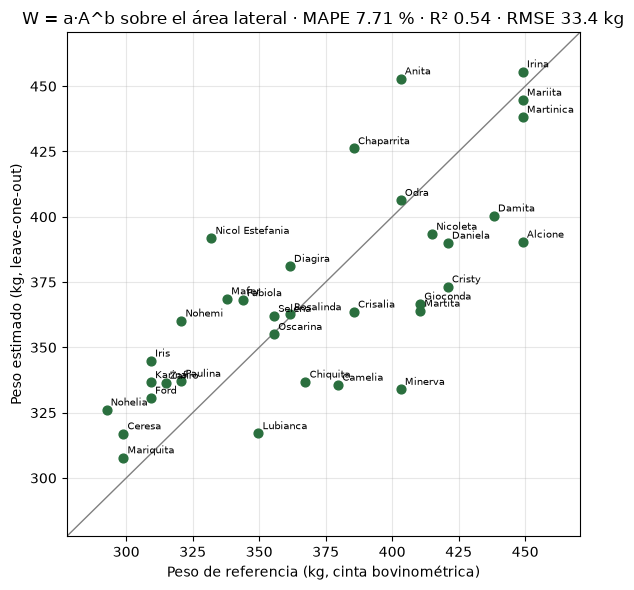

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y, pred_loglog, s=40, color="#2a6f3e", zorder=3)
for w, p, nombre in zip(y, pred_loglog, df["cow_id"]):
    ax.annotate(nombre.title(), (w, p), fontsize=7, xytext=(3, 3), textcoords="offset points")
lim = [min(y.min(), pred_loglog.min()) - 15, max(y.max(), pred_loglog.max()) + 15]
ax.plot(lim, lim, color="gray", lw=1); ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("Peso de referencia (kg, cinta bovinométrica)"); ax.set_ylabel("Peso estimado (kg, leave-one-out)")
r = resultados.loc["área log-log"]
ax.set_title(f"W = a·A^b sobre el área lateral · MAPE {r['MAPE %']:.2f} % · R² {r['R²']:.2f} · RMSE {r['RMSE kg']:.1f} kg")
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 4. Una foto con su máscara y su marcador

Salida de control del pipeline (`pipeline/data/field/fotos_hoy/qa/`): silueta segmentada y marcador detectado sobre la
foto de campo, con el área que alimenta al modelo. Se muestra la vaca con menor error absoluto porcentual y la de mayor.

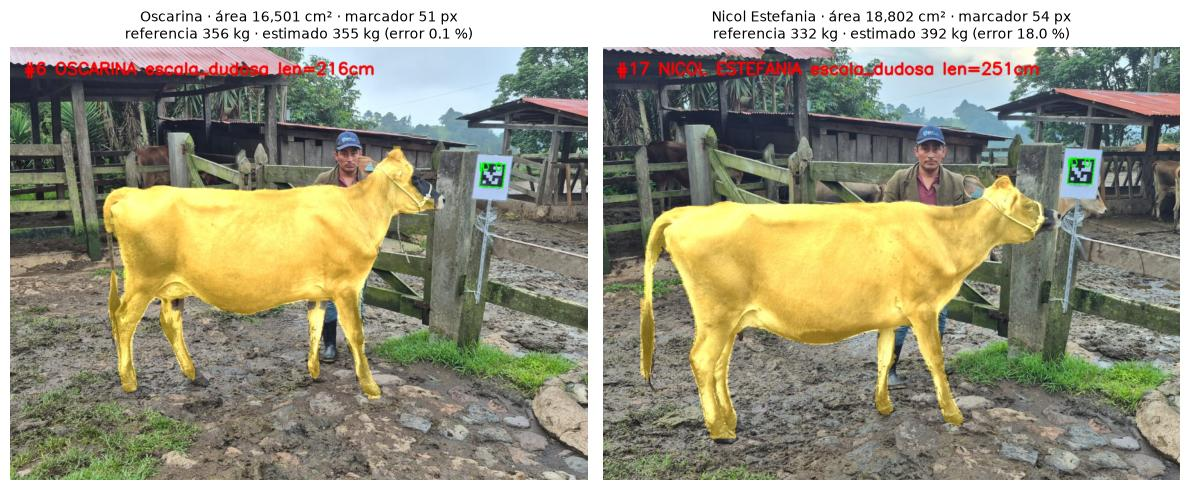

In [ ]:
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('jpeg')   # fotografías: JPEG pesa diez veces menos que PNG
ape = np.abs(pred_loglog - y) / y * 100
qa = ROOT / "pipeline/data/field/fotos_hoy/qa"
def mostrar(ax, i):
    fila = df.iloc[i]; ruta = qa / f"{int(fila.orden)}_{fila.cow_id}.jpg"
    img = cv2.cvtColor(cv2.imread(str(ruta)), cv2.COLOR_BGR2RGB)
    escala = 900 / img.shape[1]
    img = cv2.resize(img, (900, int(img.shape[0] * escala)), interpolation=cv2.INTER_AREA)
    ax.imshow(img); ax.axis("off")
    ax.set_title(f"{fila.cow_id.title()} · área {fila.lateral_area_cm2:,.0f} cm² · marcador {fila.marker_px:.0f} px\n"
                 f"referencia {fila.weight_kg:.0f} kg · estimado {pred_loglog[i]:.0f} kg (error {ape[i]:.1f} %)", fontsize=10)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
mostrar(axes[0], int(np.argmin(ape))); mostrar(axes[1], int(np.argmax(ape)))
plt.tight_layout(); plt.show()
set_matplotlib_formats('png')

## 5. Segmentador desplegado contra las 40 máscaras manuales

`informes/iou_val_manual_apk_20260909/resumen.json`: la ruta del APK (LiteRT FP32, letterbox 640×640, umbral 0.5,
vaca de mayor área) y el `.pt` de PC, evaluados sobre `pipeline/data/val_clean/` (40 imágenes, 24 animales, tres
estratos: laterales controladas, ráfagas con varias vacas, casos difíciles). La referencia son máscaras pintadas a mano.

In [ ]:
iou = json.loads((ROOT / "informes/iou_val_manual_apk_20260909/resumen.json").read_text())
filas = []
for estrato, modelos in iou["por_estrato"].items():
    for modelo, m in modelos.items():
        filas.append({"estrato": estrato, "modelo": {"apk": "ruta del APK (LiteRT)", "pt": ".pt en PC"}[modelo], "n": m["n"],
                      "eligió la vaca correcta %": m["eligio_objetivo_pct"], "sin detección": m["sin_deteccion"],
                      "IoU vaca objetivo": m["iou_objetivo"], "error de área medio %": m["err_area_medio_pct"]})
boot = iou["bootstrap_por_animal"]["apk"]["iou_objetivo"]
print(f"Diferencia APK − .pt en IoU (bootstrap por animal, n = {boot['n_grupos']}): {boot['dif_media']:+.3f}, IC95 {boot['ic95']}")
pd.DataFrame(filas).set_index(["estrato", "modelo"])

Diferencia APK − .pt en IoU (bootstrap por animal, n = 24): +0.024, IC95 [-0.0061, 0.0723]


n  eligió la vaca correcta %  sin detección  IoU vaca objetivo  error de área medio %
estrato modelo                                                                                                       
facil   .pt en PC              15                      100.0              0              0.929                    4.2
        ruta del APK (LiteRT)  15                      100.0              0              0.924                    3.8
media   .pt en PC              15                       86.7              0              0.780                   10.7
        ruta del APK (LiteRT)  15                       86.7              0              0.770                   12.3
dificil .pt en PC              10                       80.0              2              0.748                  -16.3
        ruta del APK (LiteRT)  10                      100.0              0              0.932                    4.9
total   .pt en PC              40                       90.0              2              0.828                    1.5
        ruta del APK (LiteRT)  40                       95.0              0              0.868                    7.2

## 6. Paridad entre PC y teléfono, y tiempos en el Galaxy A25

`informes/paridad_segmentador_20260909/resumen.json`: la emulación de la ruta del APK en PC frente a lo que registró
el A25 sobre las mismas 10 fotos, y LiteRT frente al `.pt`. `informes/benchmark_a25_20260826_fullres.json`: tiempos
medidos en el dispositivo (una corrida de calentamiento y cinco medidas por foto).

In [ ]:
par = json.loads((ROOT / "informes/paridad_segmentador_20260909/resumen.json").read_text())["A_benchmark_a25"]
bm = json.loads((ROOT / "informes/benchmark_a25_20260826_fullres.json").read_text())
aruco_ms = np.mean([a["aruco_ms"] for a in bm["aruco"]])
pd.DataFrame({"valor": [
    f"{par['dets_iguales_pc_vs_a25']} de {par['n_fotos']}",
    f"{par['dif_area_pc_litert_vs_a25_pct']['media']:+.3f} % media · |máx| {par['dif_area_pc_litert_vs_a25_pct']['abs_max']:.3f} %",
    f"{par['dif_area_litert_vs_pt_pct']['media']:+.3f} % media · |máx| {par['dif_area_litert_vs_pt_pct']['abs_max']:.3f} % (criterio ≤ 1 %: {'cumple' if par['criterio_area_le_1pct'] else 'no cumple'})",
    f"{bm['device']['model_name']} · Android {bm['device']['os_version']} · {bm['device']['total_memory_mb']} MB",
    f"{bm['summary']['fp32']['p50_ms']:.0f} / {bm['summary']['fp32']['p95_ms']:.0f} ms ({bm['summary']['fp32']['count']} medidas)",
    f"{bm['summary']['aruco_decoded']} de {bm['summary']['aruco_total']} · {aruco_ms:.0f} ms por foto",
    f"{bm['cold_start_ms']/1000:.2f} s",
]}, index=["Mismas detecciones PC vs A25", "Área PC-LiteRT vs A25", "Área LiteRT vs .pt", "Dispositivo",
           "Segmentación FP32 p50 / p95", "Marcador decodificado (resolución fuente)", "Arranque en frío"])

,valor
Mismas detecciones PC vs A25,10 de 10
Área PC-LiteRT vs A25,-0.014 % media · |máx| 0.205 %
Área LiteRT vs .pt,-0.252 % media · |máx| 0.619 % (criterio ≤ 1 %...
Dispositivo,SM-A256E · Android 16 · 7398 MB
Segmentación FP32 p50 / p95,456 / 470 ms (50 medidas)
Marcador decodificado (resolución fuente),10 de 10 · 1408 ms por foto
Arranque en frío,3.97 s


## 7. Golden de la app

`app/assets/model_bundle/golden_cases.json`: diez áreas medidas en el A25 con el peso que la app debe devolver. La app
los verifica con `npm run test:golden` (tolerancia 0.01 kg); aquí se recalculan con los coeficientes del paquete.

In [ ]:
golden = json.loads((ROOT / "app/assets/model_bundle/golden_cases.json").read_text())
g = pd.DataFrame(golden["casos"])
g["peso_calculado_kg"] = (golden["a"] * g["area_cm2"] ** golden["b"]).round(2)
g["diferencia_kg"] = (g["peso_calculado_kg"] - g["peso_esperado_kg"]).round(3)
print(f"Diferencia máxima: {g['diferencia_kg'].abs().max():.3f} kg (tolerancia {golden['tolerancia_kg']} kg)")
g

Diferencia máxima: 0.000 kg (tolerancia 0.01 kg)


,foto,area_cm2,peso_esperado_kg,peso_calculado_kg,diferencia_kg
0,01_camelia,15137.75,335.08,335.08,0.0
1,02_paulina,14631.90,327.14,327.14,0.0
2,03_nohelia,14944.85,332.06,332.06,0.0
3,04_ford,14591.22,326.50,326.50,0.0
4,05_karina,14777.56,329.44,329.44,0.0
5,06_selena,17289.09,368.04,368.04,0.0
6,07_chiquita,15365.17,338.63,338.63,0.0
7,08_mafer,17061.78,364.62,364.62,0.0
8,09_daniela,19070.18,394.42,394.42,0.0
9,10_mariita,22520.05,443.55,443.55,0.0


## Resumen

Los valores de arriba son los que aparecen en la documentación del repositorio: el modelo alométrico sobre el área
lateral predice el peso de las 34 vacas del piloto con el MAPE e intervalo de la tabla del apartado 2; la app lleva esos
coeficientes en su paquete y los aplica de forma exacta (apartado 7); el segmentador desplegado mide las mismas áreas
en el teléfono que en PC (apartado 6) y recupera la vaca correcta sobre las máscaras manuales (apartado 5).